# HOUSE PRICE PREDICTION

## Problem Statement
It is our job to predict the sales price for each house. For each Id in the test set, you must predict the value of the SalePrice variable.

## Importing Libararies

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Data

In [156]:
df= pd.read_csv("train.csv")

In [157]:
test_df = pd.read_csv("dataset.csv")

In [158]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [159]:
test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## EDA

In [160]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [161]:
test_df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

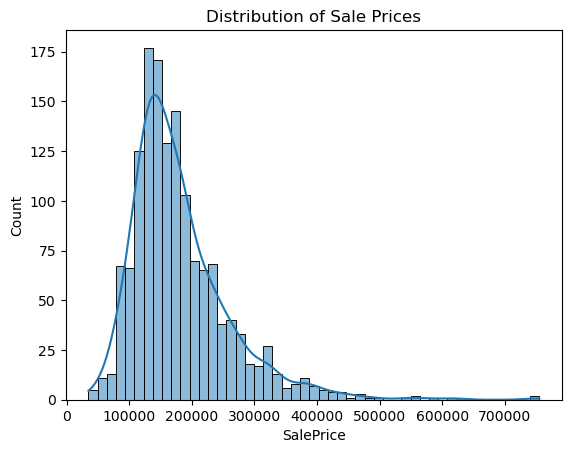

In [162]:
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of Sale Prices")
plt.show()
df['SalePrice'] = np.log1p(df['SalePrice'])

In [163]:
df.corr(numeric_only=True).SalePrice.sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.817185
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
GarageYrBlt      0.541073
TotRmsAbvGrd     0.534422
Fireplaces       0.489450
MasVnrArea       0.430809
BsmtFinSF1       0.372023
LotFrontage      0.355879
WoodDeckSF       0.334135
OpenPorchSF      0.321053
2ndFlrSF         0.319300
HalfBath         0.313982
LotArea          0.257320
BsmtFullBath     0.236224
BsmtUnfSF        0.221985
BedroomAbvGr     0.209043
ScreenPorch      0.121208
PoolArea         0.069798
MoSold           0.057330
3SsnPorch        0.054900
BsmtFinSF2       0.004832
BsmtHalfBath    -0.005149
Id              -0.017942
MiscVal         -0.020021
OverallCond     -0.036868
YrSold          -0.037263
LowQualFinSF    -0.037963
MSSubClass      -0.073959
KitchenAbvGr    -0.147548
EnclosedPorch   -0.149050
Name: SalePr

In [164]:
df.isnull().mean().sort_values(ascending=False).head(10)

PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
MasVnrType      0.597260
FireplaceQu     0.472603
LotFrontage     0.177397
GarageQual      0.055479
GarageFinish    0.055479
GarageType      0.055479
dtype: float64

In [165]:
test_df.MSZoning.unique()

array(['RH', 'RL', 'RM', 'FV', 'C (all)', nan], dtype=object)

In [166]:
test_df.SaleType.unique()

array(['WD', 'COD', 'New', 'ConLD', 'Oth', 'Con', 'ConLw', 'ConLI', 'CWD',
       nan], dtype=object)

## Feature Engineering

In [167]:
df['SalePrice'] = np.log1p(df['SalePrice'])
test_df['SalePrice'] = np.log1p(df['SalePrice'])

In [168]:
df['TotalBath']= (df.FullBath + 0.5* df.HalfBath + df.BsmtFullBath + 0.5*df.BsmtHalfBath) 
test_df['TotalBath']= (test_df.FullBath + 0.5* test_df.HalfBath + test_df.BsmtFullBath) 

In [169]:
df['TotalPorchSF']= (df.OpenPorchSF + df.ScreenPorch + df.WoodDeckSF)
test_df['TotalPorchSF']= (test_df.OpenPorchSF + test_df.ScreenPorch + test_df.WoodDeckSF)

In [170]:
df['TotalSF']= (df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF'])
test_df['TotalSF']= (test_df['TotalBsmtSF'] + test_df['1stFlrSF'] + test_df['2ndFlrSF'])

In [171]:
df['HouseAge'] = (df['YearBuilt'] - df['YearRemodAdd'])
test_df['HouseAge'] = (test_df['YearBuilt'] - test_df['YearRemodAdd'])

In [172]:
df['TotalRooms'] = (df['TotRmsAbvGrd']/df['BedroomAbvGr'])
test_df['TotalRooms'] = (test_df['TotRmsAbvGrd']/test_df['BedroomAbvGr'])

In [173]:
df['TotalArea'] = (df['TotalBsmtSF'] +df['1stFlrSF'] +df['2ndFlrSF'] +df['GarageArea'])
test_df['TotalArea'] = (test_df['TotalBsmtSF'] +test_df['1stFlrSF'] +test_df['2ndFlrSF'] +test_df['GarageArea'])


## Data Cleaning

In [174]:
df=df.drop(columns=['BsmtFinSF2','MiscVal','LowQualFinSF','YrSold' ,
                    'OverallCond','MSSubClass','EnclosedPorch','KitchenAbvGr','PoolQC', 
                    'MiscFeature', 'Alley', 'Fence','3SsnPorch','Id','FullBath','HalfBath','BsmtFullBath','BsmtHalfBath' ])
test_df=test_df.drop(columns=['BsmtFinSF2','MiscVal','LowQualFinSF','YrSold' ,
                    'OverallCond','MSSubClass','EnclosedPorch','KitchenAbvGr','PoolQC', 
                    'MiscFeature', 'Alley', 'Fence','3SsnPorch','Id','FullBath','HalfBath','BsmtFullBath','BsmtHalfBath' ])

In [175]:
df['LotFrontage']= df['LotFrontage'].fillna(df['LotFrontage'].median())
test_df['LotFrontage']= test_df['LotFrontage'].fillna(test_df['LotFrontage'].median())

In [176]:
df['MSZoning'] = df['MSZoning'].fillna(df['MSZoning'].mode()[0])
test_df['MSZoning'] = test_df['MSZoning'].fillna(test_df['MSZoning'].mode()[0])

In [177]:
df['SaleType'] = df['SaleType'].fillna(df['SaleType'].mode()[0])
test_df['SaleType'] = test_df['SaleType'].fillna(test_df['SaleType'].mode()[0])

In [178]:
df= pd.get_dummies(df, drop_first=True)
test_df = pd.get_dummies(test_df, drop_first=True)

In [179]:
df=df.fillna(0)
test_df=test_df.fillna(0)

## Training Model

In [180]:
df = df.replace([np.inf, -np.inf],0)
test_df = test_df.replace([np.inf, -np.inf],0)
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']
y = np.log1p(y)

In [181]:
from sklearn.model_selection import train_test_split
tts = train_test_split
X_train , X_test , y_train , y_test = tts(X, y,test_size=0.2, random_state=42 )

In [182]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
clf= LinearRegression()
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
from sklearn.model_selection import cross_val_score
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
scores = cross_val_score(pipeline, X, y, scoring='neg_mean_squared_error', cv=10)
rmse = np.sqrt(-scores.mean())
print(rmse)

0.00401383437150495


In [183]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [184]:
clf.fit(X_train,y_train)

LinearRegression()

## Model Evaluation

In [185]:
from sklearn.model_selection import cross_val_predict

In [186]:
reg_pred = clf.predict(X_test)
print(reg_pred)

[1.26867213 1.28664228 1.25963738 1.27095033 1.28463094 1.25506874
 1.27886353 1.2694132  1.25371419 1.26632378 1.26857305 1.26399372
 1.2543414  1.27679337 1.27230331 1.26617396 1.27471229 1.26610953
 1.26257834 1.27702836 1.27124571 1.27641995 1.27237412 1.2668901
 1.27538746 1.2689798  1.27478515 1.26291772 1.27343809 1.27496332
 1.2733849  1.28235868 1.27639822 1.26319893 1.28068364 1.26943249
 1.26988037 1.27540818 1.28421929 1.26208298 1.26701909 1.27770745
 1.26325017 1.28810184 1.26604969 1.268972   1.2617439  1.26587186
 1.29327498 1.26913152 1.26371922 1.27671059 1.26086064 1.28422062
 1.27125535 1.27933004 1.27584706 1.26979287 1.26705867 1.2586464
 1.25505426 1.27019293 1.28448367 1.28014922 1.28338181 1.27500564
 1.2628432  1.28509354 1.26515419 1.27169499 1.26527932 1.2658114
 1.26310944 1.25606566 1.29378279 1.27482741 1.28438488 1.28487989
 1.26935726 1.26466647 1.26247686 1.25715434 1.26305561 1.26092194
 1.26954713 1.26674395 1.28156005 1.27502351 1.26827074 1.2743474

In [187]:
from sklearn.metrics import r2_score

In [188]:
score =r2_score(y_test,reg_pred)
print(score)

0.7687041344673502


## Conclusion

The Linear Regression model achieved 76% accuracy in predicting house prices, demonstrating that structured feature engineering and proper data preprocessing can yield meaningful results with even a simple baseline model.

## Submission

In [189]:
missing = set(df.columns) - set(test_df.columns)
extra   = set(test_df.columns) - set(df.columns)

print(f"Missing from test_df ({len(missing)}): {missing}")
print(f"Extra in test_df ({len(extra)}): {extra}")

Missing from test_df (16): {'Condition2_RRAe', 'Condition2_RRNn', 'GarageQual_Fa', 'RoofMatl_Membran', 'Electrical_Mix', 'RoofMatl_Roll', 'RoofMatl_CompShg', 'Heating_GasA', 'HouseStyle_2.5Fin', 'Utilities_NoSeWa', 'RoofMatl_Metal', 'Exterior1st_Stone', 'Exterior2nd_Other', 'Exterior1st_ImStucc', 'Condition2_RRAn', 'Heating_OthW'}
Extra in test_df (0): set()


In [190]:
test_df_aligned = test_df.reindex(columns=X.columns, fill_value=0)
clf.predict(test_df_aligned.values)

array([13.53882483, 16.26039724, 16.49945315, ..., 19.05422211,
       12.86867067, 15.6109963 ])

In [191]:
# Load fresh test data for Id only AFTER alignment
test_data = pd.read_csv('train.csv')

# Check lengths first
print(len(test_data))        # should be 1459 or 1460
print(len(test_df_aligned))  # check this too
print(len(Predictions))

# Fix: reset index on test_data to match
test_id = test_data['Id'].reset_index(drop=True)
Predictions_series = pd.Series(Predictions).reset_index(drop=True)

submission = pd.DataFrame({
    'Id': test_id,
    'SalePrice': Predictions_series
})

submission.to_csv('submission.csv', index=False)
print(submission.shape)  # should be (1459, 2) or (1460, 2)

1460
1459
1459
(1460, 2)
